### Part A - Image Feature Extraction and Classification

In [99]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [100]:
import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

In [101]:
DATASET_PATH = r"D:\\ML\\202618023_Drashti_DS605\\202618023_Lab_06\\448"

In [102]:
CLASS_NAMES = {
    "Cracks": 1,
    "NonCracks": 0
}

In [103]:
for folder, label in CLASS_NAMES.items():

    folder_path = os.path.join(DATASET_PATH, folder)

    images = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(".jpg")
    ]

    print(f"{folder}: {len(images)} images")

Cracks: 200 images
NonCracks: 200 images


In [104]:
crack_folder = os.path.join(DATASET_PATH, "Cracks")

image_files = [
    file for file in os.listdir(crack_folder)
    if file.lower().endswith(".jpg")
]

image_path = os.path.join(crack_folder, image_files[0])

image = cv2.imread(image_path)

print("Image shape:", image.shape)

Image shape: (448, 448, 3)


In [105]:
print("Shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())

Shape: (448, 448, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


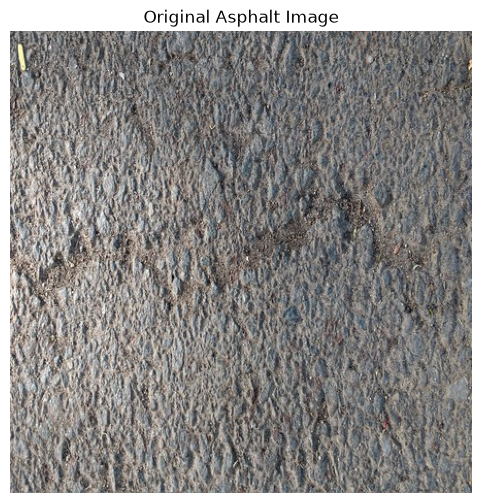

In [106]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original Asphalt Image")
plt.show()

In [107]:
TARGET_SIZE = (448, 448)
resized = cv2.resize(image, TARGET_SIZE)
print("Original shape:", image.shape)
print("Resized shape:", resized.shape)

Original shape: (448, 448, 3)
Resized shape: (448, 448, 3)


Transfrom RGB to GrayScale

In [108]:
gray = cv2.cvtColor(
    resized,
    cv2.COLOR_BGR2GRAY
)
print("Grayscale shape:", gray.shape)
print("Data type:", gray.dtype)

Grayscale shape: (448, 448)
Data type: uint8


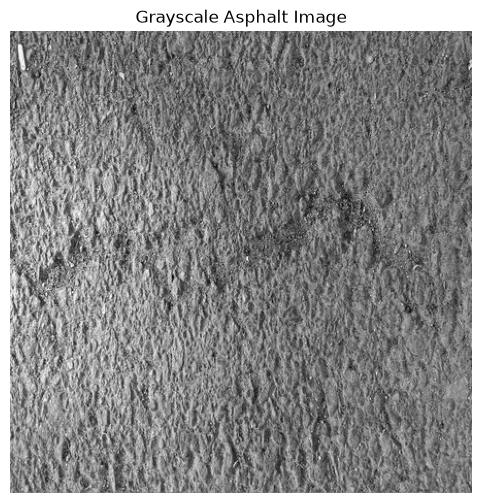

In [109]:
plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Grayscale Asphalt Image")
plt.show()

In [110]:
print("Minimum:", gray.min())
print("Maximum:", gray.max())
print("Mean:", gray.mean())

Minimum: 0
Maximum: 255
Mean: 122.09614656409438


### Mean Brightness

In [111]:
mean_brightness = np.mean(gray)

print("Mean brightness:", mean_brightness)

Mean brightness: 122.09614656409438


### Contrast

In [112]:
contrast = np.std(gray)

print("Contrast:", contrast)

Contrast: 38.01434479318785


### Dark Pixel Ratio

In [113]:
dark_pixels = gray < 50

dark_pixel_ratio = np.mean(dark_pixels)

print("Dark pixel ratio:", dark_pixel_ratio)

Dark pixel ratio: 0.01633250956632653


### Bright Pixel Ratio

In [114]:
bright_pixels = gray > 200

bright_pixel_ratio = np.mean(bright_pixels)

print("Bright pixel ratio:", bright_pixel_ratio)

Bright pixel ratio: 0.02667610012755102


### Canny Edge Detection

In [115]:
edges = cv2.Canny(
    gray,
    threshold1=100,
    threshold2=200
)

### Display Canny Edges

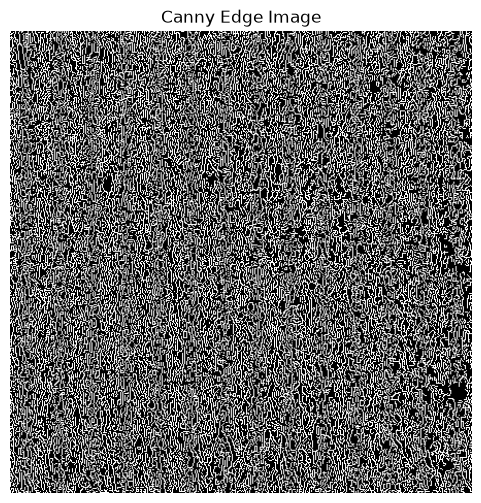

In [116]:
plt.figure(figsize=(6, 6))
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.title("Canny Edge Image")
plt.show()

### Edge Count

In [117]:
edge_count = np.sum(edges > 0)

print("Edge count:", edge_count)

Edge count: 72585


### Edge Density

In [118]:
total_pixels = gray.shape[0] * gray.shape[1]

edge_density = edge_count / total_pixels

print("Edge density:", edge_density)

Edge density: 0.3616519850127551


In [119]:
def extract_image_features(image_path):
    
    # 1. Read image using OpenCV
    image = cv2.imread(image_path)

    # Check whether image was successfully loaded
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # 2. Resize to common size
    image = cv2.resize(image, (448, 448))

    # 3. Convert BGR image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 4. Intensity features
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)

    # 5. Dark-pixel ratio
    dark_pixel_ratio = np.mean(gray < 50)

    # 6. Bright-pixel ratio
    bright_pixel_ratio = np.mean(gray > 200)

    # 7. Canny edge detection
    edges = cv2.Canny(
        gray,
        threshold1=100,
        threshold2=200
    )

    # 8. Edge count
    edge_count = np.sum(edges > 0)

    # 9. Edge density
    total_pixels = gray.shape[0] * gray.shape[1]
    edge_density = edge_count / total_pixels

    # 10. Return all features
    return {
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density
    }


In [120]:
test_folder = os.path.join(DATASET_PATH, "Cracks")

test_images = [
    file for file in os.listdir(test_folder)
    if file.lower().endswith(".jpg")
]

test_image_path = os.path.join(
    test_folder,
    test_images[0]
)

features = extract_image_features(test_image_path)

print(features)

{'mean_brightness': np.float64(122.09614656409438), 'contrast': np.float64(38.01434479318785), 'dark_pixel_ratio': np.float64(0.01633250956632653), 'bright_pixel_ratio': np.float64(0.02667610012755102), 'edge_count': np.int64(72585), 'edge_density': np.float64(0.3616519850127551)}


### Process All 400 Images

In [121]:
all_features = []

for folder, label in CLASS_NAMES.items():

    folder_path = os.path.join(DATASET_PATH, folder)

    image_files = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(".jpg")
    ]

    for filename in image_files:

        image_path = os.path.join(
            folder_path,
            filename
        )

        # Extract features
        features = extract_image_features(image_path)

        # Add image information
        features["image_name"] = filename
        features["label"] = label
        features["class_name"] = folder

        # Store result
        all_features.append(features)

print("Total feature rows:", len(all_features))

Total feature rows: 400


In [122]:
feature_df = pd.DataFrame(all_features)

print(feature_df.shape)

(400, 9)


In [123]:
feature_df.head()

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,image_name,label,class_name
0,122.096147,38.014345,0.016333,0.026676,72585,0.361652,IMG_20180513_164959951_HDR resized_448.jpg,1,Cracks
1,131.822704,29.319148,0.006741,0.011759,65773,0.327711,IMG_20180513_165129852_HDR resized_448.jpg,1,Cracks
2,121.171217,35.572563,0.024992,0.020712,63187,0.314827,IMG_20180513_165150613_HDR resized_448.jpg,1,Cracks
3,130.117701,32.745086,0.008889,0.014917,71668,0.357083,IMG_20180513_165345878_HDR resized_448.jpg,1,Cracks
4,131.079998,33.199356,0.009741,0.016791,71719,0.357337,IMG_20180513_165349788_HDR resized_448.jpg,1,Cracks


In [124]:
print(feature_df["class_name"].value_counts())

class_name
Cracks       200
NonCracks    200
Name: count, dtype: int64


In [125]:
print(feature_df["label"].value_counts())

label
1    200
0    200
Name: count, dtype: int64


Check for Missing Values

In [126]:
print(feature_df.isnull().sum())

mean_brightness       0
contrast              0
dark_pixel_ratio      0
bright_pixel_ratio    0
edge_count            0
edge_density          0
image_name            0
label                 0
class_name            0
dtype: int64


In [127]:
feature_df.describe()

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,label
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,150.873519,32.033602,0.008732,0.084392,62783.990000,0.312819,0.500000
std,17.756517,9.577624,0.019036,0.064557,13465.291275,0.067090,0.500626
min,110.355299,17.144549,0.000000,0.001440,15945.000000,0.079445,0.000000
25%,134.365630,23.670657,0.000005,0.025903,55198.250000,0.275023,0.000000
50%,152.752220,31.847127,0.001308,0.075472,67399.500000,0.335815,0.500000
75%,166.007000,38.952272,0.010578,0.120380,72714.750000,0.362298,1.000000
max,189.694804,63.906473,0.190709,0.302181,78602.000000,0.391631,1.000000


Save the Extracted Feature Table

In [128]:
feature_df.to_csv(
    "asphalt_image_features.csv",
    index=False
)

### Validate the Extracted Feature Table

In [129]:
print("Shape:", feature_df.shape)

print("\nFirst 5 rows:")
print(feature_df.head())

print("\nMissing values:")
print(feature_df.isnull().sum())

Shape: (400, 9)

First 5 rows:
   mean_brightness   contrast  dark_pixel_ratio  bright_pixel_ratio  \
0       122.096147  38.014345          0.016333            0.026676   
1       131.822704  29.319148          0.006741            0.011759   
2       121.171217  35.572563          0.024992            0.020712   
3       130.117701  32.745086          0.008889            0.014917   
4       131.079998  33.199356          0.009741            0.016791   

   edge_count  edge_density                                  image_name  \
0       72585      0.361652  IMG_20180513_164959951_HDR resized_448.jpg   
1       65773      0.327711  IMG_20180513_165129852_HDR resized_448.jpg   
2       63187      0.314827  IMG_20180513_165150613_HDR resized_448.jpg   
3       71668      0.357083  IMG_20180513_165345878_HDR resized_448.jpg   
4       71719      0.357337  IMG_20180513_165349788_HDR resized_448.jpg   

   label class_name  
0      1     Cracks  
1      1     Cracks  
2      1     Cracks  
3  

### Visualize Original Image + Canny Edges

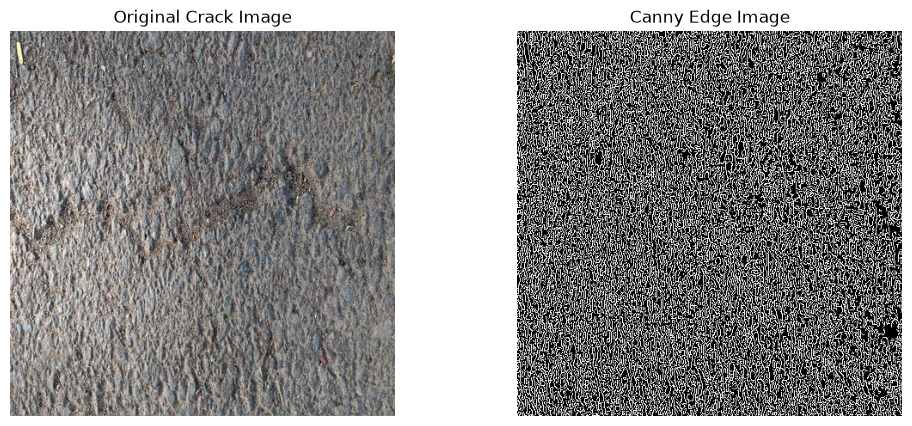

In [130]:
# Select one crack image
crack_folder = os.path.join(DATASET_PATH, "Cracks")

image_files = [
    f for f in os.listdir(crack_folder)
    if f.lower().endswith(".jpg")
]

image_path = os.path.join(crack_folder, image_files[0])

# Read image
image = cv2.imread(image_path)

# Resize
image = cv2.resize(image, (448, 448))

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Canny edges
edges = cv2.Canny(gray, 100, 200)

# Convert BGR → RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")

plt.show()

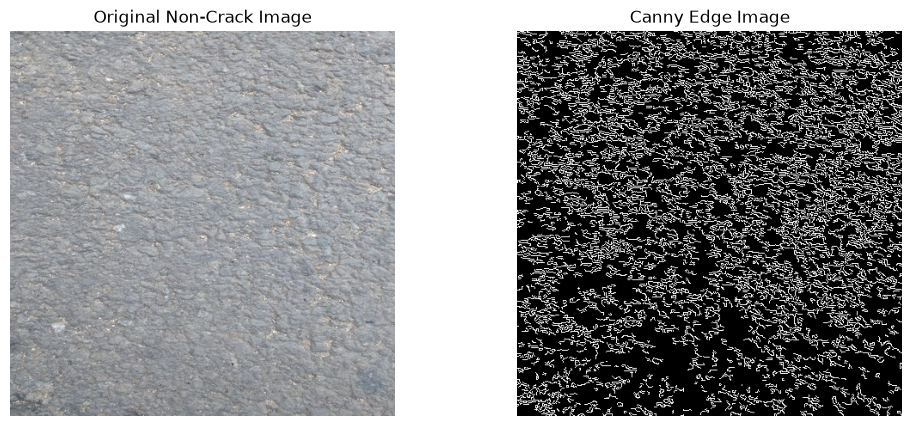

In [131]:
noncrack_folder = os.path.join(DATASET_PATH, "NonCracks")

image_files = [
    f for f in os.listdir(noncrack_folder)
    if f.lower().endswith(".jpg")
]

image_path = os.path.join(
    noncrack_folder,
    image_files[0]
)

image = cv2.imread(image_path)

image = cv2.resize(image, (448, 448))

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

edges = cv2.Canny(
    gray,
    100,
    200
)

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Non-Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")

plt.show()

### Compare Feature Distributions

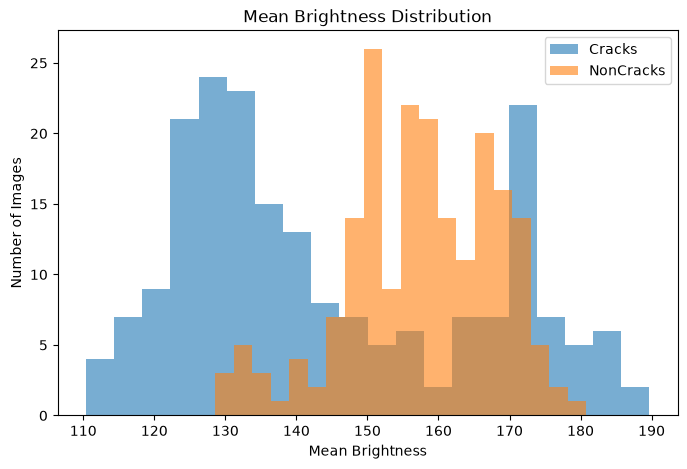

In [132]:
plt.figure(figsize=(8, 5))

plt.hist(
    feature_df.loc[
        feature_df["label"] == 1,
        "mean_brightness"
    ],
    bins=20,
    alpha=0.6,
    label="Cracks"
)

plt.hist(
    feature_df.loc[
        feature_df["label"] == 0,
        "mean_brightness"
    ],
    bins=20,
    alpha=0.6,
    label="NonCracks"
)

plt.xlabel("Mean Brightness")
plt.ylabel("Number of Images")
plt.title("Mean Brightness Distribution")
plt.legend()

plt.show()

Compare Feature Means by Class

In [133]:
feature_columns = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]
print(
    feature_df.groupby("class_name")[feature_columns].mean()
)

            mean_brightness   contrast  dark_pixel_ratio  bright_pixel_ratio  \
class_name                                                                     
Cracks           144.244057  35.310512          0.014283            0.094933   
NonCracks        157.502980  28.756693          0.003182            0.073852   

            edge_count  edge_density  
class_name                            
Cracks       67917.515      0.338396  
NonCracks    57650.465      0.287241  


### Separate X and y

In [134]:
X = feature_df[feature_columns]

y = feature_df["label"]

In [135]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 6)
y shape: (400,)


In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [137]:
print("Training distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training distribution:
label
1    160
0    160
Name: count, dtype: int64

Testing distribution:
label
0    40
1    40
Name: count, dtype: int64


### Scaling

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn scaling parameters ONLY from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (320, 6)
X_test_scaled shape: (80, 6)


In [139]:
print("Training means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining standard deviations:")
print(X_train_scaled.std(axis=0))

Training means:
[ 3.88578059e-16  4.08006962e-16 -5.96744876e-17 -2.77555756e-17
  2.02615702e-16  3.35842465e-16]

Training standard deviations:
[1. 1. 1. 1. 1. 1.]


### Train Our First Baseline Model

In [140]:
from sklearn.linear_model import LogisticRegression

In [141]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
model

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [142]:
import time

start_time = time.perf_counter()

model.fit(X_train_scaled, y_train)

training_time = time.perf_counter() - start_time

print("Training time:", training_time, "seconds")

Training time: 0.010635099999490194 seconds


In [143]:
start_time = time.perf_counter()

y_pred = model.predict(X_test_scaled)

prediction_time = time.perf_counter() - start_time

print("Prediction time:", prediction_time, "seconds")

Prediction time: 0.0008811000006971881 seconds


### Accuracy

In [144]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.85


### Precision, Recall and F1

In [145]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.8181818181818182
Recall: 0.9
F1-score: 0.8571428571428571


In [146]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[32  8]
 [ 4 36]]


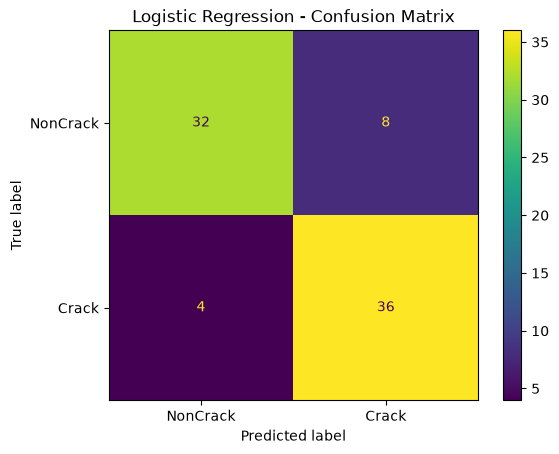

In [147]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [148]:
baseline_result = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Training Time (s)": training_time,
    "Prediction Time (s)": prediction_time
}

print(baseline_result)

{'Model': 'Logistic Regression', 'Accuracy': 0.85, 'Precision': 0.8181818181818182, 'Recall': 0.9, 'F1-score': 0.8571428571428571, 'Training Time (s)': 0.010635099999490194, 'Prediction Time (s)': 0.0008811000006971881}


Logistic Regression achieved 85% accuracy on the test set. The model obtained a precision of 81.82%, recall of 90%, and F1-score of 85.71%. The confusion matrix shows that 36 out of 40 actual crack images were correctly detected, while 4 cracks were missed. Among the 40 non-crack images, 32 were correctly classified and 8 were incorrectly classified as cracks. The higher recall indicates that the baseline model detected most of the actual cracks, although it produced some false-positive predictions.

### Train a Decision Tree Classifier

In [149]:
from sklearn.tree import DecisionTreeClassifier

In [150]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [151]:
import time

start_time = time.perf_counter()

dt_model.fit(X_train, y_train)

dt_training_time = time.perf_counter() - start_time

print("Decision Tree training time:",
      dt_training_time,
      "seconds")

Decision Tree training time: 0.005769399998825975 seconds


In [152]:
start_time = time.perf_counter()

dt_pred = dt_model.predict(X_test)

dt_prediction_time = time.perf_counter() - start_time

print("Decision Tree prediction time:",
      dt_prediction_time,
      "seconds")

Decision Tree prediction time: 0.0043655999998009065 seconds


In [153]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred)

dt_recall = recall_score(y_test, dt_pred)

dt_f1 = f1_score(y_test, dt_pred)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)

Accuracy : 0.8625
Precision: 0.8536585365853658
Recall   : 0.875
F1-score : 0.8641975308641975


In [154]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[34  6]
 [ 5 35]]


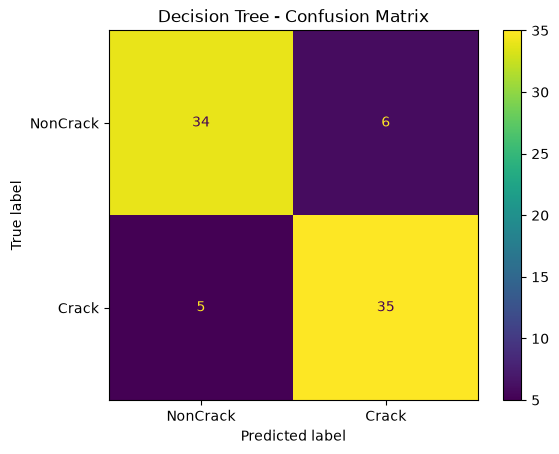

In [155]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [156]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time
    },
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1-score": dt_f1,
        "Training Time (s)": dt_training_time,
        "Prediction Time (s)": dt_prediction_time
    }
])

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.8500,0.818182,0.900,0.857143,0.010635,0.000881
1,Decision Tree,0.8625,0.853659,0.875,0.864198,0.005769,0.004366


Two traditional classifiers were evaluated using the same train-test split and handcrafted image features. Logistic Regression achieved 85.00% accuracy, 81.82% precision, 90.00% recall, and an F1-score of 85.71%. The Decision Tree achieved 86.25% accuracy, 85.37% precision, 87.50% recall, and an F1-score of 86.42%. Thus, the Decision Tree produced slightly higher accuracy, precision, and F1-score, while Logistic Regression achieved higher recall. Logistic Regression also required less training and prediction time in this experiment.

### Random Forest Classifier

In [157]:
from sklearn.ensemble import RandomForestClassifier

In [158]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [159]:
import time

start_time = time.perf_counter()

rf_model.fit(X_train, y_train)

rf_training_time = time.perf_counter() - start_time

print(
    "Random Forest training time:",
    rf_training_time,
    "seconds"
)

Random Forest training time: 0.29415069999959087 seconds


In [160]:
start_time = time.perf_counter()

rf_pred = rf_model.predict(X_test)

rf_prediction_time = time.perf_counter() - start_time

print(
    "Random Forest prediction time:",
    rf_prediction_time,
    "seconds"
)

Random Forest prediction time: 0.013942899999165093 seconds


In [161]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

Accuracy : 0.95
Precision: 0.9285714285714286
Recall   : 0.975
F1-score : 0.9512195121951219


In [162]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print(rf_cm)

[[37  3]
 [ 1 39]]


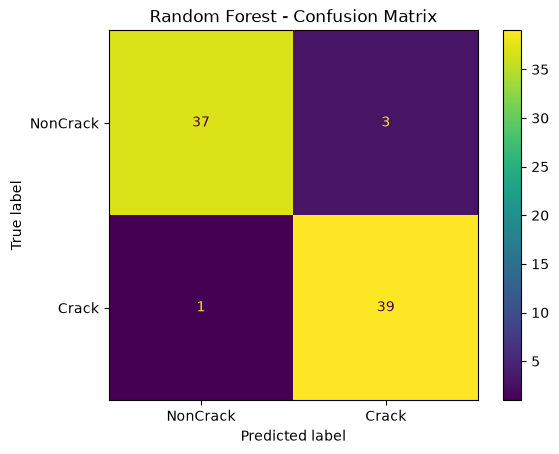

In [163]:
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["NonCrack", "Crack"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [164]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time
    },
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1-score": dt_f1,
        "Training Time (s)": dt_training_time,
        "Prediction Time (s)": dt_prediction_time
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1-score": rf_f1,
        "Training Time (s)": rf_training_time,
        "Prediction Time (s)": rf_prediction_time
    }
])

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.8500,0.818182,0.900,0.857143,0.010635,0.000881
1,Decision Tree,0.8625,0.853659,0.875,0.864198,0.005769,0.004366
2,Random Forest,0.9500,0.928571,0.975,0.951220,0.294151,0.013943


### Part B - Text Vectorization and Spam Classification

In [165]:
import pandas as pd

# Load dataset
df = pd.read_csv("emails.csv")


print("Shape:", df.shape)

Shape: (5172, 3002)


In [166]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'net', 

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [167]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), str(1)
memory usage: 118.5 MB


In [168]:
print("\nMissing Values:")
print(df.isnull().sum().sum())


Missing Values:
0


In [169]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [170]:
print("Prediction values:")
print(df["Prediction"].value_counts())

Prediction values:
Prediction
0    3672
1    1500
Name: count, dtype: int64


In [171]:
print("\nPrediction percentages:")
print(df["Prediction"].value_counts(normalize=True) * 100)


Prediction percentages:
Prediction
0    70.99768
1    29.00232
Name: proportion, dtype: float64


In [172]:
print("Unique labels:", sorted(df["Prediction"].unique()))

Unique labels: [np.int64(0), np.int64(1)]


In [173]:
print("Number of columns:", len(df.columns))

print("\nFirst 20 columns:")
print(df.columns[:20].tolist())

print("\nLast 10 columns:")
print(df.columns[-10:].tolist())

Number of columns: 3002

First 20 columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have']

Last 10 columns:
['connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military', 'allowing', 'ff', 'dry', 'Prediction']


In [174]:
print(df.dtypes.value_counts())

int64    3001
str         1
Name: count, dtype: int64


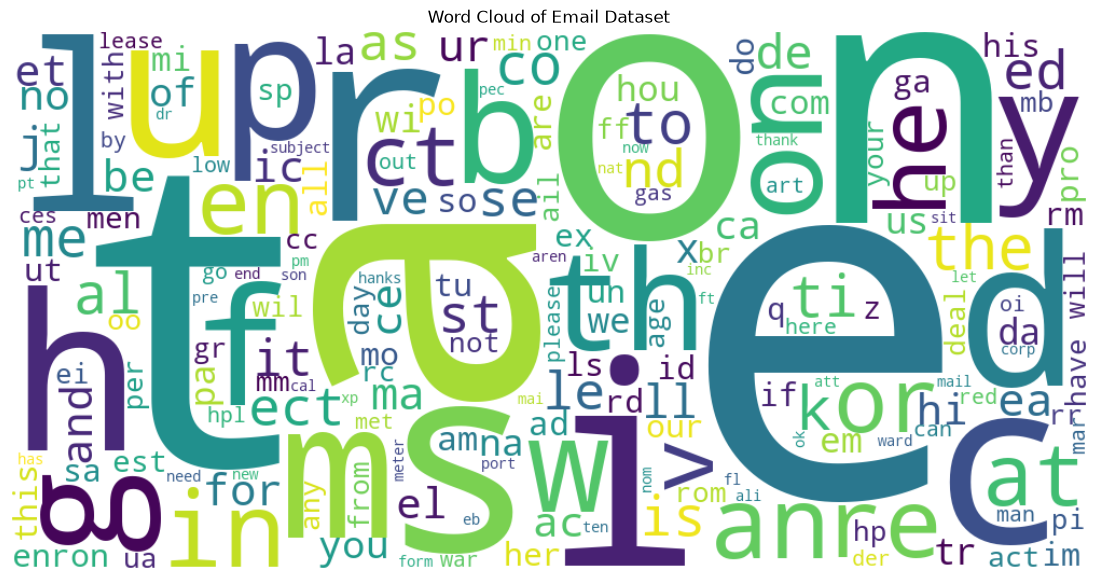

In [175]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Select the word columns
word_columns = df.columns[1:-1]

# Calculate total frequency of each word
word_frequencies = df[word_columns].sum()

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(word_frequencies)

# Display
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Email Dataset")
plt.show()

#### Understand the Target

In [176]:
print("Prediction distribution:")
print(df["Prediction"].value_counts())

print("\nPrediction percentage:")
print(
    df["Prediction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Prediction distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Prediction percentage:
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64


In [177]:
X = df.drop(columns=["Prediction", "Email No.", "Total_Word_Count"], errors="ignore")
y = df["Prediction"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5172, 3000)
y shape: (5172,)


In [178]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5172, 3000)
y shape: (5172,)


In [179]:
print(X.iloc[:5, :15])

   the  to  ect  and  for  of    a  you  hou  in  on  is  this  enron   i
0    0   0    1    0    0   0    2    0    0   0   0   1     0      0   2
1    8  13   24    6    6   2  102    1   27  18  21  13     0      1  61
2    0   0    1    0    0   0    8    0    0   4   2   0     0      0   8
3    0   5   22    0    5   1   51    2   10   1   5   9     2      0  16
4    7   6   17    1    5   2   57    0    9   3  12   2     2      0  30


In [180]:
print("\nMinimum feature value:", X.min().min())
print("Maximum feature value:", X.max().max())


Minimum feature value: 0
Maximum feature value: 2327


In [181]:
max_value = X.max().max()
max_word = X.max().idxmax()

print("Word with maximum feature value:", max_word)
print("Maximum feature value:", max_value)

Word with maximum feature value: e
Maximum feature value: 2327


In [182]:
total_values = X.shape[0] * X.shape[1]

zero_values = (X == 0).sum().sum()

sparsity = zero_values / total_values

print("Total feature values:", total_values)
print("Zero values:", zero_values)
print("Sparsity:", sparsity)
print("Sparsity percentage:", sparsity * 100)

Total feature values: 15516000
Zero values: 14641889
Sparsity: 0.943663895333849
Sparsity percentage: 94.3663895333849


In [183]:
print("Prediction distribution:")
print(df["Prediction"].value_counts())

print("\nPrediction percentages:")
print(
    df["Prediction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nUnique labels:")
print(sorted(df["Prediction"].unique()))

Prediction distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Prediction percentages:
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64

Unique labels:
[np.int64(0), np.int64(1)]


In [184]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4137, 3000)
X_test : (1035, 3000)
y_train: (4137,)
y_test : (1035,)


In [185]:
print("Training distribution:")
print(y_train.value_counts())
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting distribution:")
print(y_test.value_counts())
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64
Prediction
0    70.99
1    29.01
Name: proportion, dtype: float64

Testing distribution:
Prediction
0    735
1    300
Name: count, dtype: int64
Prediction
0    71.01
1    28.99
Name: proportion, dtype: float64


In [186]:
X_train.shape
X_test.shape
y_train.value_counts()
y_test.value_counts()

Prediction
0    735
1    300
Name: count, dtype: int64

### Train Multinomial Naive Bayes

In [187]:
from sklearn.naive_bayes import MultinomialNB
import time

# Create model
nb_model = MultinomialNB()

# Training
start_train = time.time()
nb_model.fit(X_train, y_train)
train_time = time.time() - start_train

# Prediction
start_pred = time.time()
y_pred_nb = nb_model.predict(X_test)
prediction_time = time.time() - start_pred

print("Training Time:", train_time, "seconds")
print("Prediction Time:", prediction_time, "seconds")

Training Time: 0.10814046859741211 seconds
Prediction Time: 0.0952904224395752 seconds


In [188]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Multinomial Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

print("\nConfusion Matrix:")
print(cm_nb)

Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.9420289855072463
Precision: 0.8680981595092024
Recall   : 0.9433333333333334
F1 Score : 0.9041533546325878

Confusion Matrix:
[[692  43]
 [ 17 283]]


### Logistic Regression

In [189]:
from sklearn.linear_model import LogisticRegression
import time

lr_model = LogisticRegression(max_iter=1000, random_state=42)

start_train = time.time()
lr_model.fit(X_train, y_train)
train_time_lr = time.time() - start_train

start_pred = time.time()
y_pred_lr = lr_model.predict(X_test)
prediction_time_lr = time.time() - start_pred

print("Training Time:", train_time_lr, "seconds")
print("Prediction Time:", prediction_time_lr, "seconds")

Training Time: 9.869483947753906 seconds
Prediction Time: 0.08868932723999023 seconds


In [190]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

print("\nConfusion Matrix:")
print(cm_lr)

Logistic Regression Results
---------------------------
Accuracy : 0.9826086956521739
Precision: 0.9577922077922078
Recall   : 0.9833333333333333
F1 Score : 0.9703947368421053

Confusion Matrix:
[[722  13]
 [  5 295]]


In [191]:
print("Model Performance Comparison")
print("----------------------------")

print("\nMultinomial Naive Bayes")
print("Training Time   :", train_time, "seconds")
print("Prediction Time :", prediction_time, "seconds")

print("\nLogistic Regression")
print("Training Time   :", train_time_lr, "seconds")
print("Prediction Time :", prediction_time_lr, "seconds")

Model Performance Comparison
----------------------------

Multinomial Naive Bayes
Training Time   : 0.10814046859741211 seconds
Prediction Time : 0.0952904224395752 seconds

Logistic Regression
Training Time   : 9.869483947753906 seconds
Prediction Time : 0.08868932723999023 seconds


Logistic Regression achieved higher classification performance, while Multinomial Naive Bayes provided much faster training.

### Part C - Improve the Representation

For text classification i want to reduce time performance so i want to try reduce feature.

In [192]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=1000)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Improved number of features:", X_train_selected.shape[1])

Original number of features: 3000
Improved number of features: 1000


In [193]:
from sklearn.linear_model import LogisticRegression
import time

lr_selected = LogisticRegression(max_iter=1000, random_state=42)

start_train = time.time()
lr_selected.fit(X_train_selected, y_train)
train_time_selected = time.time() - start_train

start_pred = time.time()
y_pred_selected = lr_selected.predict(X_test_selected)
prediction_time_selected = time.time() - start_pred

print("Training Time:", train_time_selected, "seconds")
print("Prediction Time:", prediction_time_selected, "seconds")

Training Time: 4.7299909591674805 seconds
Prediction Time: 0.006016731262207031 seconds


In [194]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_selected = accuracy_score(y_test, y_pred_selected)
precision_selected = precision_score(y_test, y_pred_selected)
recall_selected = recall_score(y_test, y_pred_selected)
f1_selected = f1_score(y_test, y_pred_selected)
cm_selected = confusion_matrix(y_test, y_pred_selected)

print("Improved Logistic Regression Results")
print("------------------------------------")
print("Accuracy :", accuracy_selected)
print("Precision:", precision_selected)
print("Recall   :", recall_selected)
print("F1 Score :", f1_selected)

print("\nConfusion Matrix:")
print(cm_selected)

Improved Logistic Regression Results
------------------------------------
Accuracy : 0.9729468599033816
Precision: 0.9473684210526315
Recall   : 0.96
F1 Score : 0.9536423841059603

Confusion Matrix:
[[719  16]
 [ 12 288]]


the original 3,000 word-frequency features were reduced to 1,000 informative features using Chi-Square feature selection. This reduced the feature dimensionality by 66.7% and significantly reduced both training and prediction time. However, classification performance decreased slightly, with accuracy falling from 98.26% to 97.29% and F1-score from 0.9703 to 0.9536. Therefore, reducing the number of features improves computational efficiency at the cost of a small decrease in predictive performance.

image features/Canny thresholds

In [195]:
edges = cv2.Canny(
    gray,
    threshold1=50,
    threshold2=150
)

edge_count = np.sum(edges > 0)
edge_density = edge_count / edges.size

In [197]:
X_improved = feature_df[
    ["mean_brightness",
     "contrast",
     "dark_pixel_ratio",
     "bright_pixel_ratio",
     "edge_count",
     "edge_density"]
]

y_improved = feature_df["label"]

print("X shape:", X_improved.shape)
print("y shape:", y_improved.shape)

X shape: (400, 6)
y shape: (400,)


In [198]:
from sklearn.model_selection import train_test_split

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    stratify=y_improved,
    random_state=42
)

print("Training samples:", X_train_imp.shape[0])
print("Testing samples:", X_test_imp.shape[0])

Training samples: 320
Testing samples: 80


In [199]:
from sklearn.preprocessing import StandardScaler

scaler_imp = StandardScaler()

X_train_imp = scaler_imp.fit_transform(X_train_imp)
X_test_imp = scaler_imp.transform(X_test_imp)

In [200]:
from sklearn.linear_model import LogisticRegression
import time

lr_improved = LogisticRegression(max_iter=1000, random_state=42)

start_train = time.time()
lr_improved.fit(X_train_imp, y_train_imp)
train_time_imp = time.time() - start_train

start_pred = time.time()
y_pred_imp = lr_improved.predict(X_test_imp)
prediction_time_imp = time.time() - start_pred

print("Improved Logistic Regression")
print("----------------------------")
print("Training Time  :", train_time_imp, "seconds")
print("Prediction Time:", prediction_time_imp, "seconds")

Improved Logistic Regression
----------------------------
Training Time  : 0.008016586303710938 seconds
Prediction Time: 0.0 seconds


In [201]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_imp = accuracy_score(y_test_imp, y_pred_imp)
precision_imp = precision_score(y_test_imp, y_pred_imp)
recall_imp = recall_score(y_test_imp, y_pred_imp)
f1_imp = f1_score(y_test_imp, y_pred_imp)
cm_imp = confusion_matrix(y_test_imp, y_pred_imp)

print("Improved Logistic Regression Results")
print("------------------------------------")
print("Accuracy :", accuracy_imp)
print("Precision:", precision_imp)
print("Recall   :", recall_imp)
print("F1 Score :", f1_imp)

print("\nConfusion Matrix:")
print(cm_imp)

Improved Logistic Regression Results
------------------------------------
Accuracy : 0.85
Precision: 0.8181818181818182
Recall   : 0.9
F1 Score : 0.8571428571428571

Confusion Matrix:
[[32  8]
 [ 4 36]]


In [202]:
import pandas as pd

comparison_part_c = pd.DataFrame({
    "Approach": [
        "Original Canny",
        "Improved Canny"
    ],
    "Canny Threshold": [
        "100, 200",
        "50, 150"
    ],
    "Accuracy": [
        0.85,
        accuracy_imp
    ],
    "Precision": [
        0.8181818182,
        precision_imp
    ],
    "Recall": [
        0.90,
        recall_imp
    ],
    "F1 Score": [
        0.8571428571,
        f1_imp
    ],
    "Training Time (s)": [
        0.006684,
        train_time_imp
    ],
    "Prediction Time (s)": [
        0.000624,
        prediction_time_imp
    ]
})

print(comparison_part_c)

         Approach Canny Threshold  Accuracy  Precision  Recall  F1 Score  \
0  Original Canny        100, 200      0.85   0.818182     0.9  0.857143   
1  Improved Canny         50, 150      0.85   0.818182     0.9  0.857143   

   Training Time (s)  Prediction Time (s)  
0           0.006684             0.000624  
1           0.008017             0.000000  


The Canny thresholds were changed from 100/200 to 50/150 to detect potentially finer crack edges. However, the change produced the same accuracy, precision, recall, and F1-score as the original representation. The training time also increased slightly. Therefore, in this experiment, lowering the Canny thresholds did not provide a classification improvement and introduced a small computational cost.